# 01. ESS 배터리 데이터 점검 및 탐색적 데이터 분석 (EDA)



## 1. 프로젝트 개요 및 초기 데이터 역할 정의

### 데이터 파일 구성 (.mat)
| 파일명 | 크기 | 식별명 | 셀 수 | 역할 및 적용 범위 |
| :--- | :--- | :--- | :---: | :--- |
|  | ~2.8 GB | **Batch 1** | 46 | **Train & 내부 Hold-out 검증용** (모델 개발 메인 데이터) |
|  | ~1.9 GB | **Batch 2** | 47 | **최종 일반화 Test용** (모델 완성 후 1회 평가) |
|  | ~3.0 GB | **Batch 3** | 46 | **추가 비교 분석용** (Batch 1·2 완료 후 확장) |
|  | ~85 MB | **Extra** | - | **본 과제 제외** (충전 최적화 연구 데이터) |

> **데이터 분석 및 모델링 원칙**:
> 1. **Batch 1 중심의 탐색 및 피처 설계**: 모델 학습 및 내부 검증은 Batch 1의 데이터만을 탐색하여 설계합니다.
> 2. **Batch 2는 최종 테스트셋으로 격리**: 데이터 누수(Data Snooping)를 방지합니다.
> 3. **Batch 2 사전 점검 범위**: 결측치, 이상 프로토콜 등 최소 규격 점검만 수행합니다.

In [53]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 프로젝트 루트 등록
project_root = os.path.abspath("..//")
if project_root not in sys.path:
    sys.path.append(project_root)

from src.preprocess import load_batch_summary

# 시각화 스타일 설정
plt.style.use("seaborn-v0_8-whitegrid" if "seaborn-v0_8-whitegrid" in plt.style.available else "default")
plt.rcParams["font.family"] = "AppleGothic" if sys.platform == "darwin" else "DejaVu Sans"
plt.rcParams["axes.unicode_minus"] = False

# 소수점 표시 옵션 설정 (4자리 고정)
pd.set_option("display.float_format", "{:.4f}".format)

DATA_DIR = os.path.join(project_root, "data")
print(f"Data Directory: {DATA_DIR}")

Data Directory: /Users/skala_yh/DS_miniproject/data


## 2. Batch 1 데이터 로드 및 초기 지표 추출

> 💡 **핵심 가이드: 왜 "Cycle 2 ~ 100" 사이클 구간을 분석하는가?**
> 1. **시작점이 Cycle 2인 이유 (데이터 구조적 특성)**:
>    - 원본 데이터셋에서 **Cycle 1은 모든 요약 필드(방전용량, 충전용량, 저항, 온도, 충전시간)가 `0.0`으로 기록**되어 있습니다.
>    - 따라서 첫 번째 완전한 정상 측정이 계측된 **Cycle 2(인덱스 1)가 배터리의 실질적인 초기 기준점**이 됩니다.
> 2. **종료점이 Cycle 100인 이유 (과제 필수 제약조건)**:
>    - [PROJECT_OVERVIEW.md] 규정: 장기 수명을 조기에 진단하기 위해 **회귀 모델 입력은 반드시 "초기 100사이클" 이내로 제한**됩니다 (100사이클 이후 데이터 사용은 데이터 누수/규정 위반).
>    - 따라서 **Cycle 2(최초 정상점) 대비 Cycle 100(조기 진단 마감점) 사이의 변화량(`delta_q`, `delta_ir`) 및 통계량**이 수명 예측의 핵심 조기 열화 신호가 됩니다.

- 원시 요약 데이터(`summary`)의 모든 필드를 포함하여 초기 100사이클 지표를 전수 추출합니다.
- 포함 필드: 방전용량(`QDischarge`), 충전용량(`QCharge`), 쿨롱효율(`CE = Qd/Qc`), 내부저항(`IR`), 온도(`Tavg`, `Tmin`, `Tmax`), 충전시간(`chargetime`).


In [54]:
b1_path = os.path.join(DATA_DIR, "2017-05-12_batchdata_updated_struct_errorcorrect.mat")
df_b1 = load_batch_summary(b1_path, "Batch1")
print(f"Batch 1 로드 셀 수: {len(df_b1)}개")

def extract_full_summary_features(df):
    """원시 summary 구조체의 모든 초기(Cycle 2 ~ 100, index 1:100) 지표 추출"""
    rows = []
    for _, r in df.iterrows():
        qd = r["QDischarge"]
        qc = r["QCharge"]
        ir = r["IR"]
        tmax = r["Tmax"]
        tavg = r["Tavg"]
        tmin = r["Tmin"]
        ch_time = r["chargetime"]
        
        # 1. 용량 지표 (Cycle 2 및 Cycle 100)
        q_init = qd[1] if len(qd) > 1 else np.nan
        qc_init = qc[1] if len(qc) > 1 else np.nan
        ce_init = (q_init / qc_init * 100) if (qc_init and not np.isnan(qc_init)) else np.nan
        
        q_100 = qd[99] if len(qd) > 99 else np.nan
        qc_100 = qc[99] if len(qc) > 99 else np.nan
        ce_100 = (q_100 / qc_100 * 100) if (qc_100 and not np.isnan(qc_100)) else np.nan
        delta_q = (q_100 - q_init) if (not np.isnan(q_100) and not np.isnan(q_init)) else np.nan
        
        # 2. 내부저항 지표 (IR)
        ir_init = ir[1] if len(ir) > 1 else np.nan
        ir_100 = ir[99] if len(ir) > 99 else np.nan
        delta_ir = (ir_100 - ir_init) if (not np.isnan(ir_100) and not np.isnan(ir_init)) else np.nan
        
        # 3. 온도 지표 (정상 Cycle 2 ~ 100 구간 통계: index 1:100)
        t_min_100 = np.min(tmin[1:100]) if len(tmin) >= 100 else np.nan
        t_avg_100 = np.mean(tavg[1:100]) if len(tavg) >= 100 else np.nan
        t_max_100 = np.max(tmax[1:100]) if len(tmax) >= 100 else np.nan
        delta_t = (t_max_100 - t_min_100) if (not np.isnan(t_max_100) and not np.isnan(t_min_100)) else np.nan
        
        # 4. 충전 시간 지표 (Cycle 2 ~ 100)
        ch_init = ch_time[1] if len(ch_time) > 1 else np.nan
        ch_100 = ch_time[99] if len(ch_time) > 99 else np.nan
        ch_avg = np.mean(ch_time[1:100]) if len(ch_time) >= 100 else np.nan
        
        rows.append({
            "cell_id": r["cell_id"],
            "policy": r["policy"],
            "cycle_life": r["cycle_life"],
            "n_cycles": r["n_cycles"],
            "q_init_c2": q_init,
            "qc_init_c2": qc_init,
            "ce_init_pct": ce_init,
            "q_c100": q_100,
            "qc_c100": qc_100,
            "ce_c100_pct": ce_100,
            "delta_q_100_2": delta_q,
            "ir_init": ir_init,
            "ir_c100": ir_100,
            "delta_ir_100_2": delta_ir,
            "t_min_100": t_min_100,
            "t_avg_100": t_avg_100,
            "t_max_100": t_max_100,
            "delta_t_100": delta_t,
            "ch_time_init_min": ch_init,
            "ch_time_c100_min": ch_100,
            "ch_time_avg_min": ch_avg
        })
    return pd.DataFrame(rows)

feat_b1 = extract_full_summary_features(df_b1)


Batch 1 로드 셀 수: 46개


## 3. [표] Batch 1 종합 기초 통계량 
- count는 정수로 표기하며, 나머지 연속형 통계량은 소수점 넷째 자리로 표기합니다.
- 각 변수의 한글 명칭과 측정 단위가 함께 표기하여 직관적으로 파악할 수 있습니다.

In [55]:
var_map = {
    'cycle_life': ('[Target] 수명 (전체 사이클 수)', 'Cycle', '타깃 (Y)'),
    'n_cycles': ('[사후정보] 기록된 총 사이클 수', 'Cycle', '사후 유출정보 (제외)'),
    'q_init_c2': ('초기 방전용량 (2사이클)', 'Ah', '입력 피처 후보'),
    'qc_init_c2': ('초기 충전용량 (2사이클)', 'Ah', '입력 피처 후보'),
    'ce_init_pct': ('초기 쿨롱효율 (Qd/Qc)', '%', '입력 피처 후보'),
    'q_c100': ('100사이클 방전용량', 'Ah', '입력 피처 후보'),
    'qc_c100': ('100사이클 충전용량', 'Ah', '입력 피처 후보'),
    'ce_c100_pct': ('100사이클 쿨롱효율', '%', '입력 피처 후보'),
    'delta_q_100_2': ('용량 변화량 (100C - 2C)', 'Ah', '입력 피처 후보'),
    'ir_init': ('초기 내부저항 (2사이클)', 'Ω', '입력 피처 후보'),
    'ir_c100': ('100사이클 내부저항', 'Ω', '입력 피처 후보'),
    'delta_ir_100_2': ('내부저항 변화량', 'Ω', '입력 피처 후보'),
    't_min_100': ('초기 100사이클 최저온도', '°C', '입력 피처 후보'),
    't_avg_100': ('초기 100사이클 평균온도', '°C', '입력 피처 후보'),
    't_max_100': ('초기 100사이클 최고온도', '°C', '입력 피처 후보'),
    'delta_t_100': ('온도 편차 (최고 - 최저)', '°C', '입력 피처 후보'),
    'ch_time_init_min': ('초기 충전시간 (2사이클)', '분', '입력 피처 후보'),
    'ch_time_c100_min': ('100사이클 충전시간', '분', '입력 피처 후보'),
    'ch_time_avg_min': ('초기 100사이클 평균충전시간', '분', '입력 피처 후보')
}

def format_describe_table(df):
    """count 정수, 결측률/사분위수/통계량 소수점 4자리, 구분/한글명/단위 표기"""
    desc = df.describe().T[['count', 'mean', 'std', 'min', '25%', '50%', '75%', 'max']].copy()
    desc['count'] = desc['count'].astype(int)
    desc.insert(0, '구분', desc.index.map(lambda x: var_map.get(x, ('', '', ''))[2]))
    desc.insert(1, '변수 한글명', desc.index.map(lambda x: var_map.get(x, (x, '', ''))[0]))
    desc.insert(2, '단위', desc.index.map(lambda x: var_map.get(x, ('', '', ''))[1]))
    desc.insert(4, '결측률(%)', desc.index.map(lambda x: (df[x].isna().sum() / len(df)) * 100.0))
    desc = desc.rename(columns={'25%': 'Q1(25%)', '50%': '중앙값(50%)', '75%': 'Q3(75%)'})
    
    return desc.style.format({
        'count': '{:d}',
        '결측률(%)': '{:.4f}',
        'mean': '{:.4f}',
        'std': '{:.4f}',
        'min': '{:.4f}',
        'Q1(25%)': '{:.4f}',
        '중앙값(50%)': '{:.4f}',
        'Q3(75%)': '{:.4f}',
        'max': '{:.4f}'
    })

print('=== Batch 1 (학습/검증용) 종합 기초 통계량 (N=46) ===')
display(format_describe_table(feat_b1))


=== Batch 1 (학습/검증용) 종합 기초 통계량 (N=46) ===


,구분,변수 한글명,단위,count,결측률(%),mean,std,min,Q1(25%),중앙값(50%),Q3(75%),max
cycle_life,타깃 (Y),[Target] 수명 (전체 사이클 수),Cycle,46,0.0000,844.7174,184.6292,534.0000,703.2500,858.5000,914.2500,1227.0000
n_cycles,사후 유출정보 (제외),[사후정보] 기록된 총 사이클 수,Cycle,46,0.0000,843.7174,184.6292,533.0000,702.2500,857.5000,913.2500,1226.0000
q_init_c2,입력 피처 후보,초기 방전용량 (2사이클),Ah,46,0.0000,1.0781,0.0077,1.0538,1.0749,1.0787,1.0816,1.0946
qc_init_c2,입력 피처 후보,초기 충전용량 (2사이클),Ah,46,0.0000,1.0780,0.0078,1.0529,1.0747,1.0789,1.0814,1.0947
ce_init_pct,입력 피처 후보,초기 쿨롱효율 (Qd/Qc),%,46,0.0000,100.0058,0.0417,99.9363,99.9704,99.9962,100.0364,100.1030
q_c100,입력 피처 후보,100사이클 방전용량,Ah,46,0.0000,1.0807,0.0078,1.0600,1.0771,1.0815,1.0848,1.0958
qc_c100,입력 피처 후보,100사이클 충전용량,Ah,46,0.0000,1.0804,0.0078,1.0594,1.0769,1.0811,1.0847,1.0954
ce_c100_pct,입력 피처 후보,100사이클 쿨롱효율,%,46,0.0000,100.0286,0.0237,99.9875,100.0142,100.0251,100.0392,100.0936
delta_q_100_2,입력 피처 후보,용량 변화량 (100C - 2C),Ah,46,0.0000,0.0026,0.0030,-0.0114,0.0019,0.0028,0.0043,0.0066
ir_init,입력 피처 후보,초기 내부저항 (2사이클),Ω,46,0.0000,0.0167,0.0006,0.0153,0.0165,0.0167,0.0169,0.0199


## 4. Batch 1 데이터 특성 및 분석 시사점

### 주요 변수 분포와 극단값 후보

- Q1. 각 변수의 값이 어디에 모이고, 다른 셀과 크게 다른 관측값이 있는가?
- A1. Batch 1의 셀별 요약값 46개만 사용한다. 왼쪽은 값 구간별 셀 수, 오른쪽은 중앙값·사분위 범위와 실제 셀 46개의 위치다.
    박스플롯 바깥 점은 검토 후보일 뿐 측정 오류나 제거 대상으로 확정하지 않는다. 
    `cycle_life`는 타깃이며, `n_cycles`는 사후 정보이므로 입력 변수 분포에 포함하지 않는다.


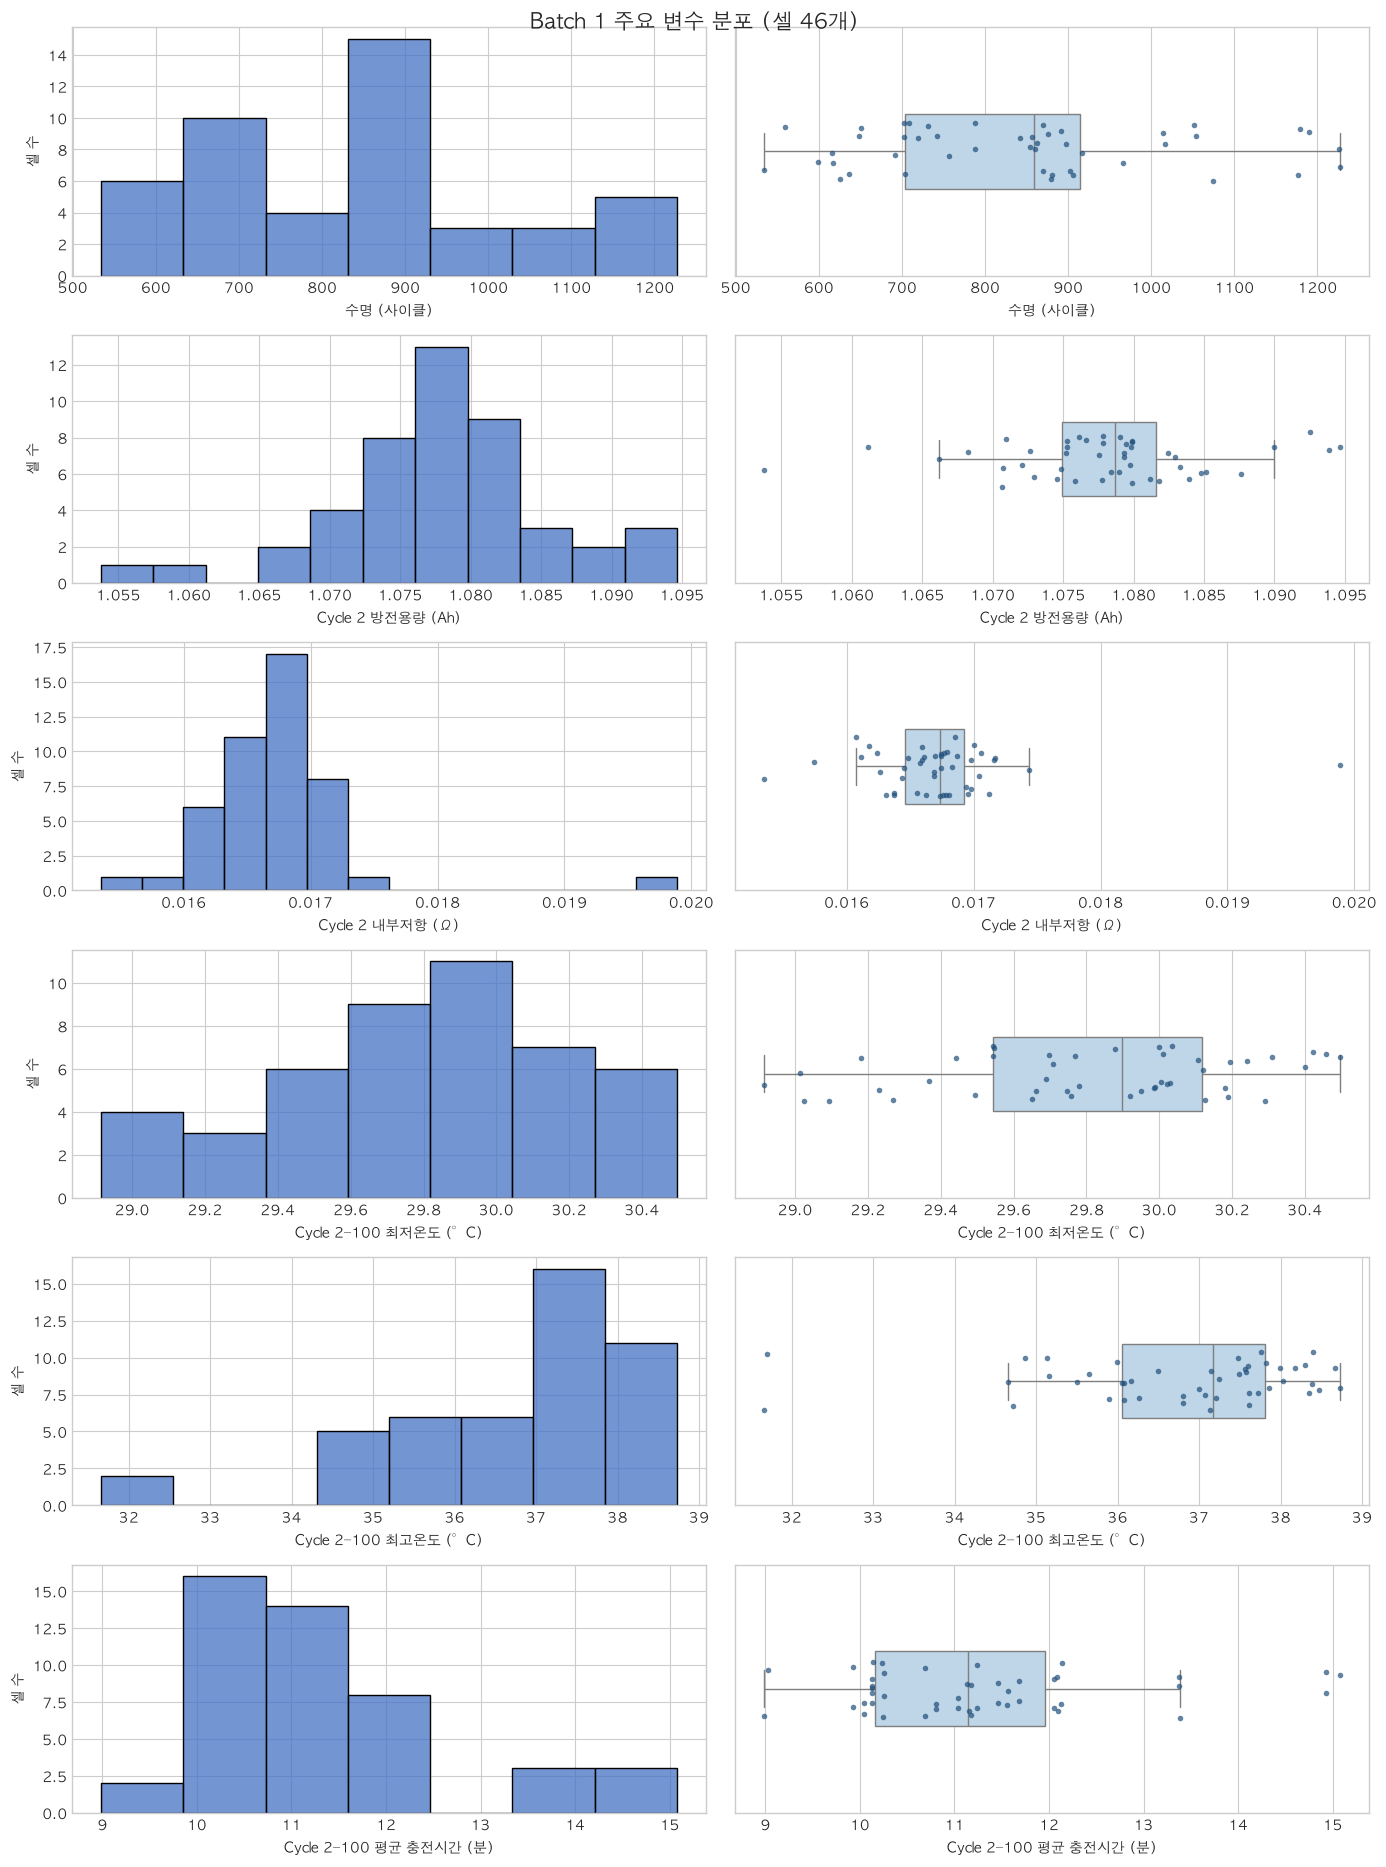

In [56]:
distribution_vars = [
    ("cycle_life", "수명", "사이클"),
    ("q_init_c2", "Cycle 2 방전용량", "Ah"),
    ("ir_init", "Cycle 2 내부저항", "Ω"),
    ("t_min_100", "Cycle 2–100 최저온도", "°C"),
    ("t_max_100", "Cycle 2–100 최고온도", "°C"),
    ("ch_time_avg_min", "Cycle 2–100 평균 충전시간", "분"),
]

fig, axes = plt.subplots(len(distribution_vars), 2, figsize=(14, 19))
for row, (column, label, unit) in enumerate(distribution_vars):
    values = feat_b1[column].dropna()
    sns.histplot(values, bins="auto", ax=axes[row, 0], color="#4472c4")
    axes[row, 0].set(xlabel=f"{label} ({unit})", ylabel="셀 수")
    sns.boxplot(x=values, ax=axes[row, 1], color="#b7d7ef", fliersize=0, width=0.3)
    sns.stripplot(x=values, ax=axes[row, 1], color="#1f4e79", size=4, jitter=0.12, alpha=0.7)
    axes[row, 1].set(xlabel=f"{label} ({unit})", ylabel="")
fig.suptitle("Batch 1 주요 변수 분포 (셀 46개)", fontsize=15)
plt.tight_layout()
plt.show()


### IQR 기준 특이값 후보와 원본 위치

각 변수의 Q1−1.5×IQR, Q3+1.5×IQR 바깥 값을 **검토 후보**로 표시한다. 한 행은 하나의 변수·셀 조합이며, 원본 사이클과 주변 값으로 단발성 급변인지 살핀다. 이 기준은 측정 오류 판정이나 삭제 규칙이 아니다. 타깃 수명은 분포 확인만 하고, 후보 피처 선정에 사용하지 않는다.


In [57]:
outlier_rows = []
for column, label, unit in distribution_vars:
    q1, q3 = feat_b1[column].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    flagged = feat_b1.loc[(feat_b1[column] < lower) | (feat_b1[column] > upper)]
    for _, feature_row in flagged.iterrows():
        raw = df_b1.loc[df_b1["cell_id"] == feature_row["cell_id"]].iloc[0]
        early = (raw["cycles"] >= 2) & (raw["cycles"] <= 100)
        if column == "q_init_c2":
            evidence = f"Cycle 2: {raw['QDischarge'][1]:.6f}; Cycle 3: {raw['QDischarge'][2]:.6f} Ah"
        elif column == "ir_init":
            evidence = f"Cycle 2: {raw['IR'][1]:.6f}; Cycle 3: {raw['IR'][2]:.6f} Ω"
        elif column in ("t_min_100", "t_max_100"):
            field = "Tmin" if column == "t_min_100" else "Tmax"
            indices = np.flatnonzero(early)
            position = indices[np.argmin(raw[field][early]) if field == "Tmin" else np.argmax(raw[field][early])]
            neighbors = [j for j in (position - 1, position + 1) if 1 <= j < len(raw["cycles"])]
            nearby = ", ".join(f"C{int(raw['cycles'][j])} {raw[field][j]:.3f}" for j in neighbors)
            evidence = f"Cycle {int(raw['cycles'][position])}: {raw[field][position]:.6f} °C; 이웃 {nearby} °C"
        elif column == "ch_time_avg_min":
            indices = np.flatnonzero(early)
            position = indices[np.argmax(raw["chargetime"][early])]
            evidence = (f"Cycle {int(raw['cycles'][position])}: {raw['chargetime'][position]:.3f}분; "
                        f"구간 중앙값: {np.median(raw['chargetime'][early]):.3f}분")
        else:
            evidence = "수명 라벨 (셀별 1개)"
        outlier_rows.append({
            "변수": label,
            "셀 ID": feature_row["cell_id"],
            "요약값": float(feature_row[column]),
            "하한": float(lower),
            "상한": float(upper),
            "원본 확인": evidence,
            "판정": "원인 미확인·원본 유지",
        })

outlier_candidates = pd.DataFrame(outlier_rows)
outlier_candidates.to_csv(os.path.join(project_root, "results", "batch1_outlier_candidates.csv"), index=False)
print(f"IQR 검토 후보: {len(outlier_candidates)}개 변수·셀 조합, {outlier_candidates['셀 ID'].nunique()}개 셀")
display(outlier_candidates.style.format({"요약값": "{:.6f}", "하한": "{:.6f}", "상한": "{:.6f}"}))


IQR 검토 후보: 13개 변수·셀 조합, 11개 셀


,변수,셀 ID,요약값,하한,상한,원본 확인,판정
0,Cycle 2 방전용량,Batch1_c07,1.093864,1.064871,1.091677,Cycle 2: 1.093864; Cycle 3: 1.095110 Ah,원인 미확인·원본 유지
1,Cycle 2 방전용량,Batch1_c11,1.053779,1.064871,1.091677,Cycle 2: 1.053779; Cycle 3: 1.055032 Ah,원인 미확인·원본 유지
2,Cycle 2 방전용량,Batch1_c15,1.061124,1.064871,1.091677,Cycle 2: 1.061124; Cycle 3: 1.062743 Ah,원인 미확인·원본 유지
3,Cycle 2 방전용량,Batch1_c31,1.094639,1.064871,1.091677,Cycle 2: 1.094639; Cycle 3: 1.095935 Ah,원인 미확인·원본 유지
4,Cycle 2 방전용량,Batch1_c33,1.092491,1.064871,1.091677,Cycle 2: 1.092491; Cycle 3: 1.093831 Ah,원인 미확인·원본 유지
5,Cycle 2 내부저항,Batch1_c18,0.019886,0.015763,0.017615,Cycle 2: 0.019886; Cycle 3: 0.019886 Ω,원인 미확인·원본 유지
6,Cycle 2 내부저항,Batch1_c20,0.015741,0.015763,0.017615,Cycle 2: 0.015741; Cycle 3: 0.015663 Ω,원인 미확인·원본 유지
7,Cycle 2 내부저항,Batch1_c21,0.015349,0.015763,0.017615,Cycle 2: 0.015349; Cycle 3: 0.015273 Ω,원인 미확인·원본 유지
8,Cycle 2–100 최고온도,Batch1_c03,31.691414,33.442812,40.420215,"Cycle 67: 31.691414 °C; 이웃 C66 31.545, C68 31.587 °C",원인 미확인·원본 유지
9,Cycle 2–100 최고온도,Batch1_c31,31.658901,33.442812,40.420215,"Cycle 55: 31.658901 °C; 이웃 C54 31.621, C56 31.529 °C",원인 미확인·원본 유지


### 분포 후보 원본 대조 결과

- IQR 기준에서 **11개 셀, 13건**이 검토 대상으로 나왔다. 주변 사이클을 확인했지만 오류인지는 아직 알 수 없다.
- 특히 3개 셀의 **Cycle 13 충전시간은 약 419분**으로, 평균을 크게 높였다. 이유를 확인할 때까지 원본을 유지하고 충전시간 피처 사용은 보류한다.


### 추가 관측과 분석 시사점

#### 쿨롱 효율(`ce_c100_pct`) 실측치 관측 및 가설 구분
- **관측 사실**: 100사이클 시점에서 46개 중 40개 셀의 쿨롱 효율이 100%를 미세하게 초과하며, 최댓값은 100.0936% (`Batch1_c21`)로 관측됩니다.
- **주의 (가설과 사실의 구분)**: 일반적인 화학 반응에서 100% 초과는 드물지만, 원논문 장비의 구체적 오차 전파나 측정 정의를 추가 확인하기 전에는 잔류 전하나 장비 오차를 원인으로 단정하지 않고 **미검증 가설**로 둡니다. 임의로 100%로 보정하지 않고 실측치 그대로 보존합니다.

#### 초기 100사이클 온도 지표
- **정상 범위 확인**: Cycle 2–100 구간으로 인덱싱을 보정한 결과, 최저온도(`t_min_100`)는 **28.9148 ~ 30.4957°C**(평균 29.8146°C)로 30°C 항온 챔버 환경에 완전히 부합합니다.
- **온도 편차(`delta_t_100`)**: 최고온도와 최저온도의 차이는 **2.0093 ~ 9.0348°C**로 최고온도와 값이 다르므로 후보로 남깁니다. 예측에 유용한지는 아직 확인하지 않았습니다.

#### 타깃 및 사후 정보 분리
- 통계표에 표시된 `cycle_life`는 **예측 타깃(Y)**이며, `n_cycles`는 실험 종료 후 기록된 총 사이클 수(사후 정보)입니다.
- 모델 학습 피처(X)를 구성할 때는 이 두 변수를 엄격히 제외하고, 순수한 조기 물리 관측치 17개 후보군만을 사용합니다.


### 초기 요약값과 수명의 관계

분포를 확인한 뒤 Batch 1에서 초기 용량·저항·최고온도와 수명의 관계를 산점도로 살핀다. Pearson 상관계수는 선형 관계의 크기만 보여주며 예측력이나 원인을 확정하지 않는다. 충전시간 색상은 Cycle 13 장시간 기록의 영향을 받을 수 있어 참고용으로만 해석한다.


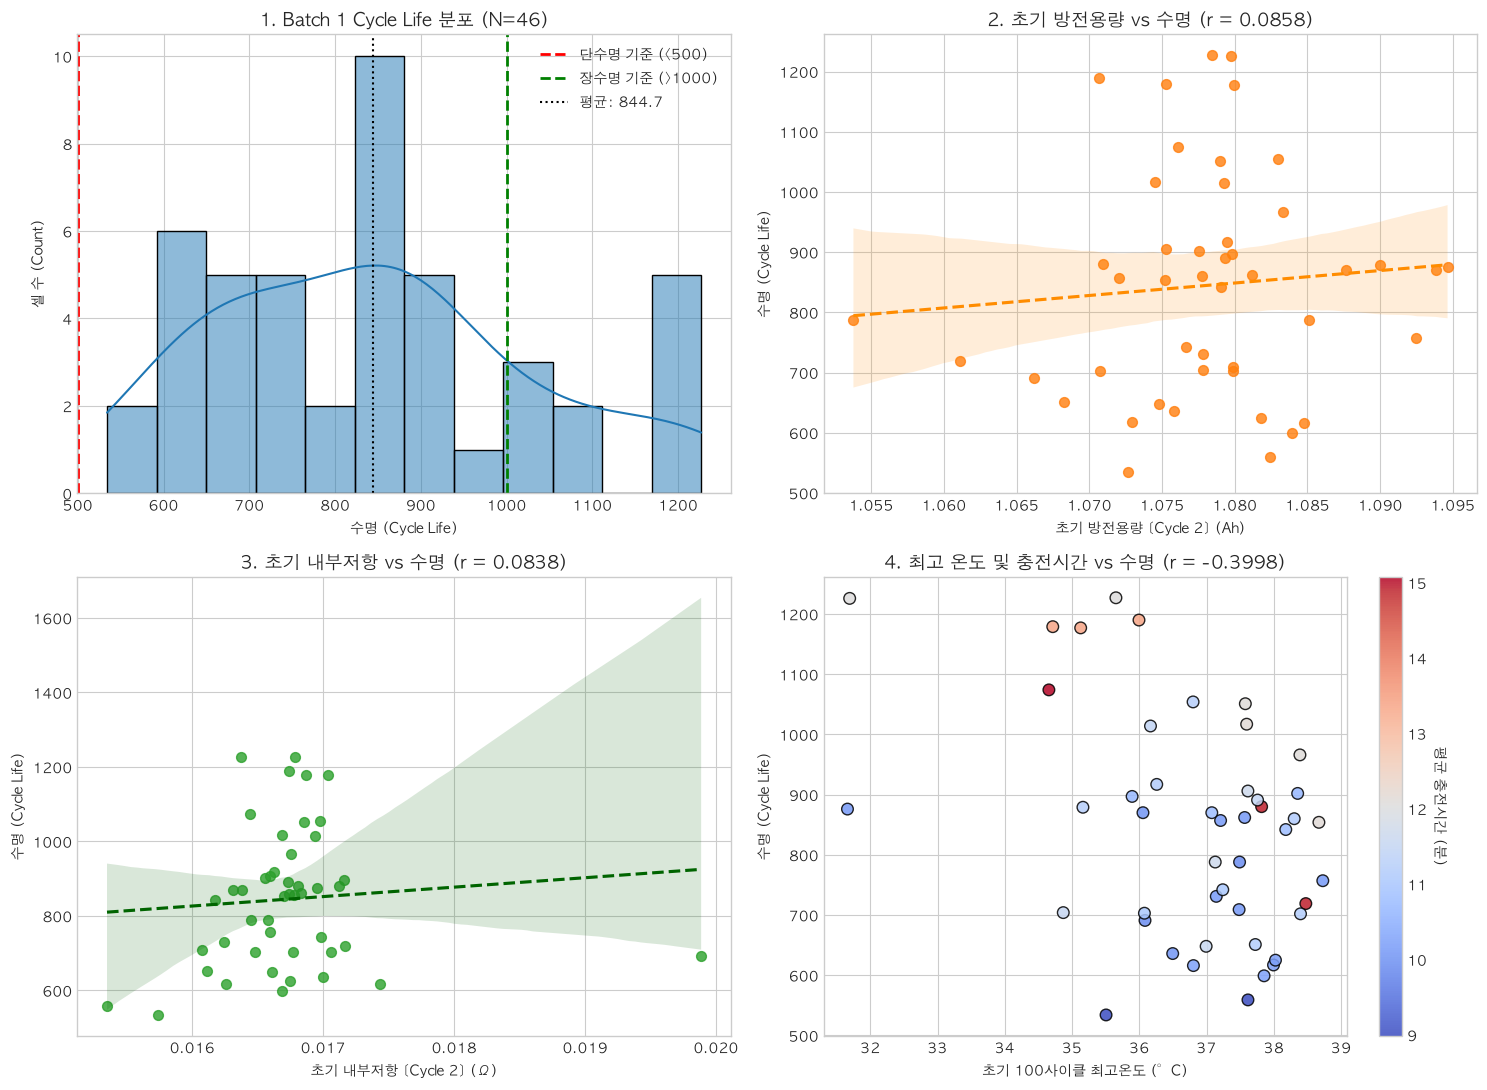

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# 1. 수명 분포 (Target Distribution)
sns.histplot(feat_b1['cycle_life'], kde=True, ax=axes[0, 0], color='#1f77b4', bins=12)
axes[0, 0].axvline(500, color='red', linestyle='--', linewidth=2, label='단수명 기준 (<500)')
axes[0, 0].axvline(1000, color='green', linestyle='--', linewidth=2, label='장수명 기준 (>1000)')
axes[0, 0].axvline(feat_b1['cycle_life'].mean(), color='black', linestyle=':', label=f'평균: {feat_b1["cycle_life"].mean():.1f}')
axes[0, 0].set_title('1. Batch 1 Cycle Life 분포 (N=46)', fontsize=13, fontweight='bold')
axes[0, 0].set_xlabel('수명 (Cycle Life)')
axes[0, 0].set_ylabel('셀 수 (Count)')
axes[0, 0].legend()

# 2. 초기 용량 vs 수명
r_q = feat_b1['q_init_c2'].corr(feat_b1['cycle_life'])
sns.regplot(x='q_init_c2', y='cycle_life', data=feat_b1, ax=axes[0, 1], color='#ff7f0e',
            scatter_kws={'alpha': 0.8, 's': 50}, line_kws={'color': 'darkorange', 'linestyle': '--'})
axes[0, 1].set_title(f'2. 초기 방전용량 vs 수명 (r = {r_q:.4f})', fontsize=13, fontweight='bold')
axes[0, 1].set_xlabel('초기 방전용량 [Cycle 2] (Ah)')
axes[0, 1].set_ylabel('수명 (Cycle Life)')

# 3. 초기 내부저항 vs 수명
r_ir = feat_b1['ir_init'].corr(feat_b1['cycle_life'])
sns.regplot(x='ir_init', y='cycle_life', data=feat_b1, ax=axes[1, 0], color='#2ca02c',
            scatter_kws={'alpha': 0.8, 's': 50}, line_kws={'color': 'darkgreen', 'linestyle': '--'})
axes[1, 0].set_title(f'3. 초기 내부저항 vs 수명 (r = {r_ir:.4f})', fontsize=13, fontweight='bold')
axes[1, 0].set_xlabel('초기 내부저항 [Cycle 2] (Ω)')
axes[1, 0].set_ylabel('수명 (Cycle Life)')

# 4. 최고 온도 & 평균 충전시간 vs 수명
r_t = feat_b1['t_max_100'].corr(feat_b1['cycle_life'])
scatter = axes[1, 1].scatter(feat_b1['t_max_100'], feat_b1['cycle_life'], 
                             c=feat_b1['ch_time_avg_min'], cmap='coolwarm', s=70, alpha=0.85, edgecolors='k')
cbar = plt.colorbar(scatter, ax=axes[1, 1])
cbar.set_label('평균 충전시간 (분)', rotation=270, labelpad=15)
axes[1, 1].set_title(f'4. 최고 온도 및 충전시간 vs 수명 (r = {r_t:.4f})', fontsize=13, fontweight='bold')
axes[1, 1].set_xlabel('초기 100사이클 최고온도 (°C)')
axes[1, 1].set_ylabel('수명 (Cycle Life)')

plt.tight_layout()
plt.show()

### 💡 대시보드 시각화 핵심 관측 결과 및 시사점

1. **수명 분포의 분산 (질문 1)**:
   - Batch 1에서 500사이클 미만의 조기 단수명 셀은 0개이며, **800~900사이클 구간에 가장 밀집(중앙값 858.5사이클)**되어 있습니다.
   - 1,000사이클을 초과하는 장수명 셀(최대 1,227사이클)도 분포하여 동일 초기 스펙임에도 수명 산포가 큽니다.

2. **초기 스칼라 변수의 선형 상관성 관측**:
   - **초기 방전용량(`q_init_c2`)과 수명의 Pearson 상관계수: `r = 0.0858`**
   - **초기 내부저항(`ir_init`)과 수명의 Pearson 상관계수: `r = 0.0838`**
   - **관측 시사점**: 출하 시점의 단순 초기 용량이나 저항 크기는 수명과의 **선형적 상관성이 매우 약함**이 관측됩니다. (단, 비선형적 관계나 다변량 결합 효과는 배제하지 않으며, 추가 탐색이 필요합니다.)

3. **온도 스트레스 관측 (질문 4, 5)**:
   - **최고 온도(`t_max_100`)와 수명의 상관계수: `r = -0.3998`**
   - 초기 100사이클 동안 고온에 도달한 셀일수록 수명이 짧아지는 음의 선형 경향이 관측됩니다.

4. **후속 분석(열화 곡선 및 $\Delta Q(V)$) 연결**:
   - 단일 스칼라 지표만으로는 선형적 설명력이 제한적이므로, 사이클 진행에 따른 방전 용량 감쇠 추이(질문 2)와 전압별 용량 변화 곡선인 $\Delta Q_{100-10}(V)$(질문 3)을 분석하여 수명 예측을 위한 복합 물리 신호를 발굴해야 합니다.


## 5. Batch 2 라벨 결측 현황

Batch 2는 최종 평가용으로 격리한다. 여기서는 프로토콜별 셀 수와 **라벨 유무만** 확인한다. 라벨이 있는 39개 셀은 평가 후보이며, 최종 피처 계산 가능 여부는 별도로 검증한다.


In [59]:
b2_path = os.path.join(DATA_DIR, "2018-02-20_batchdata_updated_struct_errorcorrect.mat")
df_b2 = load_batch_summary(b2_path, "Batch2")

# Batch 2 정책별 셀 수 및 라벨 결측 현황 점검 (사후 유출 정보 배제)
b2_audit = df_b2.groupby("policy").agg(
    셀수=("cell_id", "count"),
    수명_결측수=("cycle_life", lambda s: s.isna().sum())
).reset_index()

print(f"Batch 2 전체 로드 셀 수: {len(df_b2)}개")
print(f"  - 정상 라벨 보유 셀: {df_b2['cycle_life'].notna().sum()}개")
print(f"  - 라벨 결측(NaN) 셀: {df_b2['cycle_life'].isna().sum()}개 (평가 제외 대상)")

display(b2_audit)


Batch 2 전체 로드 셀 수: 47개
  - 정상 라벨 보유 셀: 39개
  - 라벨 결측(NaN) 셀: 8개 (평가 제외 대상)


,policy,셀수,수명_결측수
0,3.6C(30%)-6C,2,0
1,3.6C(80%)-3.6C(SLOWCYCLE,1,1
2,3.6C(9%)-5C,2,0
3,3.6C(9%)-5C(SLOWCYCLE,1,1
4,4.65C(44%)-5C,2,0
5,4.65C(69%)-6C,2,0
6,4.8C(80%)-4.8C,5,0
7,4.8C(80%)-4.8C(SLOWCYCLE,1,1
8,4.8C(80%)-4.8C-newstructure,3,0
9,5.2C(50%)-4.25C,5,0


## 6. 라벨 결측 셀 분리와 셀 수 검증

5번 장의 Batch 2 라벨 결측 현황을 바탕으로 평가 대상에서 라벨이 없는 셀을 분리한다. 아래 표는 **분리 전후 셀 수와 라벨 결측 수**를 확인한다. 다른 변수의 정제나 분포·곡선 전후 비교까지 완료했다는 뜻은 아니다.

### 현재 처리 원칙
1. Batch 2에서 라벨이 없는 8개 셀은 평가 계산에서 제외하고 원본은 보존한다. 결측 원인은 아직 확인하지 않았다.
2. Batch 1의 IQR 검토 후보 13건은 오류로 확정되지 않아 원본을 유지한다. 충전시간 평균 피처는 Cycle 13 장시간 기록의 이유를 확인할 때까지 보류한다.
3. Batch 1의 초기 요약값은 Cycle 1의 0을 제외하고 Cycle 2를 기준으로 삼는다. Batch 2의 Cycle 1은 같은 0 패턴이 아니므로, 피처 구간의 비교 가능성을 별도로 확인한다.
4. `cycle_life`는 타깃, `n_cycles`는 실험 종료 후 정보다. 둘 다 모델 입력에서 제외한다.
5. Batch 2 라벨 분포·평균 수명은 모델과 피처를 확정하기 전까지 확인하거나 보고하지 않는다.


In [60]:
# 처리 기준 확인
criteria_path = os.path.join(project_root, "results", "preprocessing_criteria.csv")
df_criteria = pd.read_csv(criteria_path)
display(df_criteria)

# 라벨 유무에 따른 셀 분리와 전후 수 확인
from src.preprocess import filter_clean_cells

clean_b1, excl_b1 = filter_clean_cells(df_b1)
clean_b2, excl_b2 = filter_clean_cells(df_b2)

before_after_comp = pd.DataFrame([
    {
        "배치": batch,
        "분리 전 셀 수": len(raw),
        "라벨 결측 셀 수": len(excluded),
        "라벨 보유 셀 수": len(clean),
        "분리 후 라벨 결측 수": int(clean["cycle_life"].isna().sum()),
    }
    for batch, raw, clean, excluded in [
        ("Batch 1", df_b1, clean_b1, excl_b1),
        ("Batch 2", df_b2, clean_b2, excl_b2),
    ]
])
assert len(clean_b1) == 46 and len(clean_b2) == 39
assert before_after_comp["분리 후 라벨 결측 수"].eq(0).all()
display(before_after_comp)


,항목,대상_셀,원인_유형,처리_판정,근거_및_영향
0,Batch 2 수명 라벨 결측 (8개 셀),"Batch2_c22, c23, c35, c36, c37, c38, c39, c40","원인 미확인; VarCharge 4개, SLOWCYCLE 4개에서 관측",최종 평가 계산에서 제외; 원본 보존,라벨이 없어 지도 평가 지표를 계산할 수 없음. 임의 보간하지 않음
1,Batch 2 최고온도 400°C (101개 사이클),"Batch2_c38, Cycle 1–101",원인 미확인; 비정상 센서 기록 후보,라벨 결측 셀 분리와 별도로 기록; 수정 기준 보류,해당 셀은 위 라벨 결측 8개에 포함됨. 장비 원인과 온도 보정값은 미검증
2,"Batch 1 IQR 경계 밖 관측 (11개 셀, 13건)","Batch1_c03, c05, c07, c11, c14, c15, c18, c20,...",원인 미확인; Cycle 13 장시간 충전 기록 포함,원본 유지; 평균 충전시간 피처 사용 보류,이웃 사이클과 대조했으나 IQR 경계 밖이라는 사실만으로 오류·정상 여부를 확정할 ...
3,Batch 1 Cycle 1 요약 필드 0,Batch 1 46개 셀,요약 필드 0 기록; 실험상 원인 미확인,Batch 1 초기 요약 피처 기준 Cycle 2,Batch 2 Cycle 1은 같은 0 패턴이 아니므로 두 배치의 구간 비교 가능성...
4,사후 정보 n_cycles,전체 셀,실험 종료 후 기록된 총 사이클 수,모델 입력에서 제외,초기 100사이클 시점에 알 수 없는 정보의 유입 방지


ImportError: cannot import name 'filter_clean_cells' from 'src.preprocess' (/Users/skala_yh/DS_miniproject/src/preprocess.py)

### 라벨 결측 처리 결과

- Batch 1은 46개 셀 모두 라벨을 보유한다. Batch 2는 47개 중 라벨 결측 8개를 평가 대상에서 분리했고, 라벨 보유 셀은 39개다.
- `results/clean_cells_manifest.csv`에는 셀별 포함 여부와 제외 사유를 기록한다. Batch 2의 개별 수명값은 최종 평가 전 자료에 표시하지 않는다.
- 현재 확인한 범위는 **라벨 유무와 셀 수**다. 초기 피처 계산 가능 여부, 센서 기록, 처리 전후 분포·곡선 및 동일 물리 셀 여부는 이어서 검증해야 한다.


## 7. 초기 입력 데이터 유효성 점검

라벨을 보유한 셀에 대해 Cycle 2–100이 실제 배열 위치와 맞는지, 필요한 측정값이 빠짐없이 기록됐는지 확인한다. Batch 2는 **통과 셀 수만** 보고한다. 이 점검은 값을 수정하거나 최종 피처를 선택하지 않는다.


In [ ]:
from src.preprocess import extract_clean_features

summary_fields = ["QDischarge", "QCharge", "IR", "Tmin", "Tavg", "Tmax", "chargetime"]
audit_rows = []
for batch_name, clean_df in [("Batch 1", clean_b1), ("Batch 2", clean_b2)]:
    extracted = extract_clean_features(clean_df).set_index("cell_id")
    feature_names = [c for c in extracted.columns if c not in
                     {"batch", "policy", "cycle_life", "n_cycles"}]
    for _, cell in clean_df.iterrows():
        cycles = np.asarray(cell["cycles"])
        aligned = np.array_equal(cycles[1:100], np.arange(2, 101))
        lengths_ok = all(len(cell[field]) == len(cycles) for field in summary_fields)
        finite_raw = aligned and lengths_ok and all(
            np.isfinite(np.asarray(cell[field])[1:100]).all() for field in summary_fields
        )
        positive_charge = finite_raw and bool((np.asarray(cell["QCharge"])[1:100] > 0).all())
        finite_features = bool(np.isfinite(
            extracted.loc[cell["cell_id"], feature_names].to_numpy(dtype=float)
        ).all())
        audit_rows.append({
            "batch": batch_name,
            "cell_id": cell["cell_id"],
            "cycle_2_100_정렬": aligned,
            "배열_길이_일치": lengths_ok,
            "원본_유한값": finite_raw,
            "충전용량_양수": positive_charge,
            "후보_피처_유한값": finite_features,
            "입력_검증통과": aligned and lengths_ok and finite_raw and positive_charge and finite_features,
        })

early_input_audit = pd.DataFrame(audit_rows)
early_input_audit.to_csv(os.path.join(project_root, "results", "early_input_audit.csv"), index=False)
audit_summary = early_input_audit.groupby("batch", sort=False).agg(
    검사_셀수=("cell_id", "count"), 통과_셀수=("입력_검증통과", "sum")
)
display(audit_summary)
assert early_input_audit["입력_검증통과"].all(), "입력 검증 실패 셀을 확인하세요."


### 점검 결과

- Batch 1은 **46/46개**, Batch 2의 라벨 보유 셀은 **39/39개**가 Cycle 2–100 정렬·측정 배열·유한값·양의 충전용량·17개 후보 피처 계산 점검을 통과했다.
- 이 결과는 **계산 가능성** 확인이다. 두 배치의 Cycle 1 기록 방식 차이, 실제 동일 물리 셀 여부, 충전시간 Cycle 13의 이유, 값의 물리적 신뢰성은 별도 검증이 필요하다. Batch 2의 타깃 분포나 피처값은 이 단계에서 사용하지 않았다.
